# Notebook 11 — Feature Importance Analysis

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

Trains a Random Forest surrogate model on MICE cluster labels to quantify the relative importance of each cognitive domain in determining cluster membership. Uses permutation importance for robust estimates.

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

RESULTS_DIR = '../results'
FIGURES_DIR = '../report template/Figures'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load shared infrastructure
with open(os.path.join(RESULTS_DIR, 'shared_infrastructure.pkl'), 'rb') as f:
    infra = pickle.load(f)

domain_columns = infra['domain_score_columns']
domain_scores = pd.DataFrame(
    infra['domain_scores']['MICE'],
    columns=domain_columns,
    index=infra['domain_score_index']
)
labels = infra['cluster_labels']['MICE']

# Exclude noise points
mask = labels >= 0
X = domain_scores.loc[mask].values
y = labels[mask]

print(f'Domain scores shape: {X.shape}')
print(f'Clusters: {len(set(y))}')
print(f'Samples (excl. noise): {len(y)}')

Domain scores shape: (22075, 6)
Clusters: 2
Samples (excl. noise): 22075


## 1. Random Forest Surrogate Model

Train a Random Forest classifier using cluster labels as the target. Cross-validate to assess surrogate quality.

In [3]:
# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'
)

# Cross-validate
cv_scores = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')
print(f'5-fold CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'Per-fold: {[f"{s:.4f}" for s in cv_scores]}')

# Fit on full data for importance
rf.fit(X_scaled, y)
print(f'\nTraining accuracy: {rf.score(X_scaled, y):.4f}')

5-fold CV accuracy: 0.9888 (+/- 0.0044)
Per-fold: ['0.9880', '0.9918', '0.9932', '0.9900', '0.9807']



Training accuracy: 1.0000


## 2. Feature Importance: Gini + Permutation

In [4]:
# Gini importance (built-in)
gini_importance = pd.Series(rf.feature_importances_, index=domain_columns)
gini_importance = gini_importance.sort_values(ascending=False)
print('=== Gini Importance ===')
for dom, imp in gini_importance.items():
    print(f'  {dom}: {imp:.4f}')

# Permutation importance (more robust)
perm_result = permutation_importance(
    rf, X_scaled, y,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    'mean': perm_result.importances_mean,
    'std': perm_result.importances_std
}, index=domain_columns).sort_values('mean', ascending=False)

print('\n=== Permutation Importance ===')
for dom, row in perm_importance.iterrows():
    print(f'  {dom}: {row["mean"]:.4f} (+/- {row["std"]:.4f})')

=== Gini Importance ===
  Visuoperception: 0.3793
  Orientation: 0.2652
  Language: 0.2490
  Attention: 0.0475
  Memory: 0.0324
  Executive Function: 0.0266



=== Permutation Importance ===
  Visuoperception: 0.2027 (+/- 0.0022)
  Language: 0.1751 (+/- 0.0019)
  Orientation: 0.1712 (+/- 0.0017)
  Attention: 0.0135 (+/- 0.0004)
  Executive Function: 0.0109 (+/- 0.0004)
  Memory: 0.0068 (+/- 0.0003)


## 3. Publication-Quality Figure

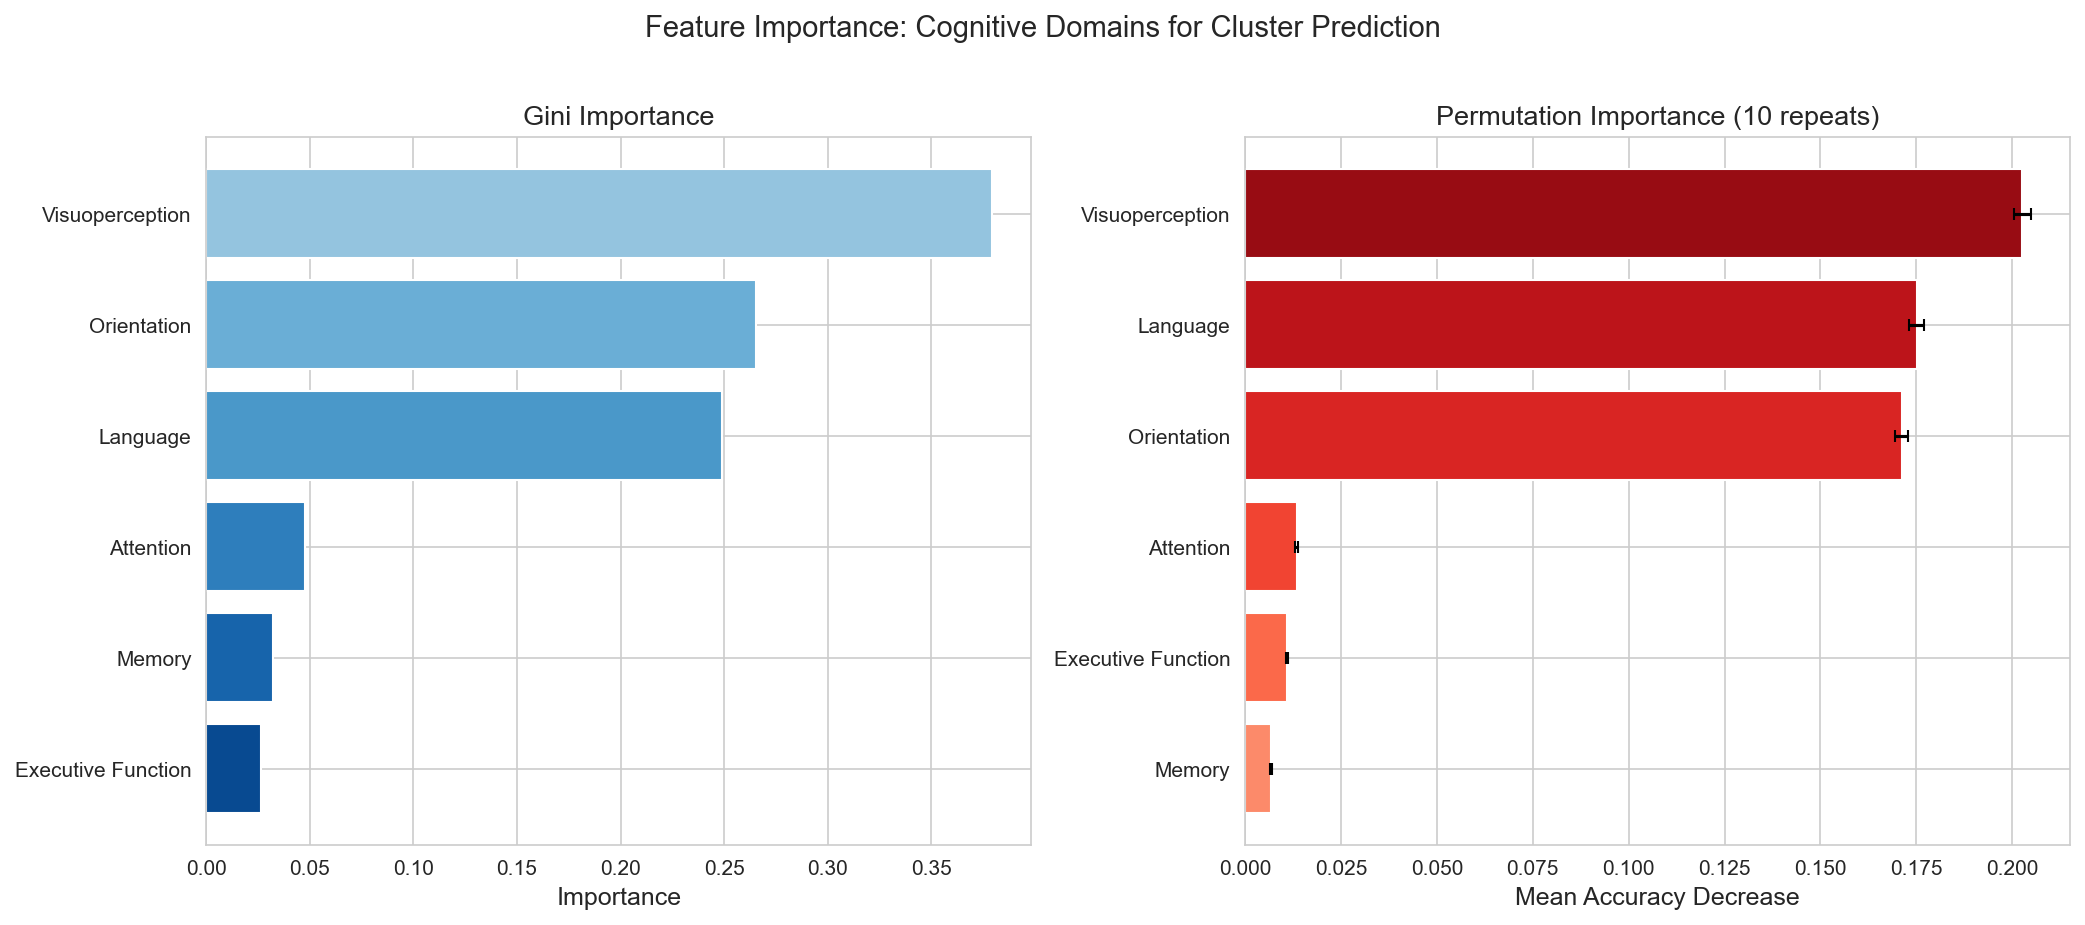

Saved: feature_importance.png


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gini importance
colors_gini = plt.cm.Blues(np.linspace(0.4, 0.9, len(gini_importance)))
ax1.barh(range(len(gini_importance)), gini_importance.values, color=colors_gini)
ax1.set_yticks(range(len(gini_importance)))
ax1.set_yticklabels(gini_importance.index)
ax1.set_xlabel('Importance', fontsize=12)
ax1.set_title('Gini Importance', fontsize=13)
ax1.invert_yaxis()

# Permutation importance with error bars
perm_sorted = perm_importance.sort_values('mean', ascending=True)
colors_perm = plt.cm.Reds(np.linspace(0.4, 0.9, len(perm_sorted)))
ax2.barh(
    range(len(perm_sorted)),
    perm_sorted['mean'].values,
    xerr=perm_sorted['std'].values,
    color=colors_perm,
    capsize=3
)
ax2.set_yticks(range(len(perm_sorted)))
ax2.set_yticklabels(perm_sorted.index)
ax2.set_xlabel('Mean Accuracy Decrease', fontsize=12)
ax2.set_title('Permutation Importance (10 repeats)', fontsize=13)

plt.suptitle('Feature Importance: Cognitive Domains for Cluster Prediction', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

In [6]:
# Save results
feature_importance_results = {
    'gini_importance': gini_importance.to_dict(),
    'permutation_importance_mean': perm_importance['mean'].to_dict(),
    'permutation_importance_std': perm_importance['std'].to_dict(),
    'cv_accuracy_mean': float(cv_scores.mean()),
    'cv_accuracy_std': float(cv_scores.std()),
    'cv_scores': cv_scores.tolist(),
    'n_estimators': 500,
    'n_samples': int(len(y)),
    'n_clusters': int(len(set(y))),
}

with open(os.path.join(RESULTS_DIR, 'feature_importance.pkl'), 'wb') as f:
    pickle.dump(feature_importance_results, f, protocol=4)

print('Saved: feature_importance.pkl')
print(f'\n=== Notebook 11 Complete ===')

Saved: feature_importance.pkl

=== Notebook 11 Complete ===
